In [71]:
from sklearn.model_selection import cross_val_score, KFold, cross_validate, RepeatedKFold
from sklearn.preprocessing import PowerTransformer, RobustScaler, StandardScaler
from sklearn.feature_selection import VarianceThreshold, RFECV, RFE
from sklearn.linear_model import LinearRegression


from ml_enhance import plot_scaled_linreg_result, CorrelationFilter


import matplotlib.pyplot as plt
from sklearn import pipeline
import seaborn as sns
import pandas as pd
import numpy as np
import scipy
import json

In [72]:
def make_pipeline(model, step_name):
    return pipeline.Pipeline([
        ("variance", VarianceThreshold(threshold=0.0)),
        ("remove_corr", CorrelationFilter(threshold=0.95)),
        ("transform", PowerTransformer(method='yeo-johnson', standardize=False)),
        ("scale", StandardScaler()),
        (step_name, model)
    ])

In [73]:
def get_faulty_X(scores: dict) -> pd.DataFrame:
    print(scores["test_r2"].min())
    idx = scores["test_r2"].argmin()
    faulty_pl: pipeline.Pipeline = scores["estimator"][idx]
    X_trans: np.ndarray = faulty_pl[:-1].transform(X)
    X_trans_df = pd.DataFrame(
        X_trans,
        columns=faulty_pl[:-1].get_feature_names_out()
    )

    return X_trans_df

In [74]:
def boxplot(X, feature):
    plt.figure(figsize=(12,6))
    plt.boxplot(X[feature])
    plt.title(f'Boxplots for transformed feature {feature}')
    plt.xticks(rotation=45)
    plt.show()

In [75]:
pl_linear = make_pipeline(LinearRegression(), "predict")

In [76]:
df = pd.read_csv("data/processed_dataset_wo_metals_w_even_more_qm.csv")

In [77]:
y = df["solubility"]
X = df.drop(["solubility", "smiles", "canon_smiles", "id"], axis=1)

In [78]:
cv = KFold(n_splits=10, shuffle=True, random_state=42)

In [79]:
scoring = {
    "r2": "r2",
    "MSE": "neg_mean_squared_error"
}

In [80]:
scores = cross_validate(pl_linear, X, y, cv=cv, scoring=scoring, n_jobs=4, return_estimator=True, return_train_score=True)

In [81]:
print(f"Train R2 scores: {scores["train_r2"]}\n\nTest R2 scores: {scores["test_r2"]}")

Train R2 scores: [0.847737   0.84911162 0.84712646 0.84797202 0.84522864 0.84792676
 0.8500153  0.84853927 0.84737758 0.84816162]

Test R2 scores: [ 7.78464089e-01  8.20783493e-01  8.38323398e-01  8.33104049e-01
  8.11801944e-01  8.35484103e-01  8.12285386e-01  8.27921888e-01
 -1.27865000e+08  8.24537068e-01]


In [82]:
X_trans_faulty = get_faulty_X(scores)

-127864999.99369943


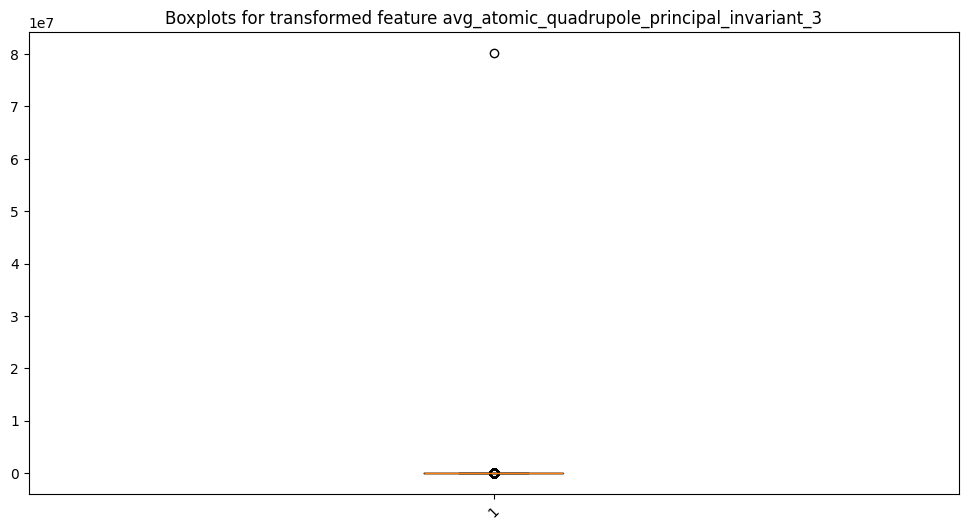

In [83]:
boxplot(X_trans_faulty, "avg_atomic_quadrupole_principal_invariant_3")

In [84]:
X = X.drop("avg_atomic_quadrupole_principal_invariant_3", axis=1)

In [85]:
scores = cross_validate(pl_linear, X, y, cv=cv, scoring=scoring, n_jobs=4, return_estimator=True, return_train_score=True)

In [86]:
print(f"Train R2 scores: {scores["train_r2"]}\n\nTest R2 scores: {scores["test_r2"]}")

Train R2 scores: [0.8477044  0.84913288 0.84714136 0.84811012 0.84531586 0.84794451
 0.85006011 0.84863462 0.84737408 0.84830529]

Test R2 scores: [-8.85244218e+02  8.21514711e-01  8.40196535e-01  8.32855897e-01
  8.04635894e-01  8.35312266e-01  8.12658985e-01  8.28101334e-01
  8.40415100e-01  8.24570979e-01]


In [93]:
X_trans_faulty = get_faulty_X(scores)

-885.2442180009298


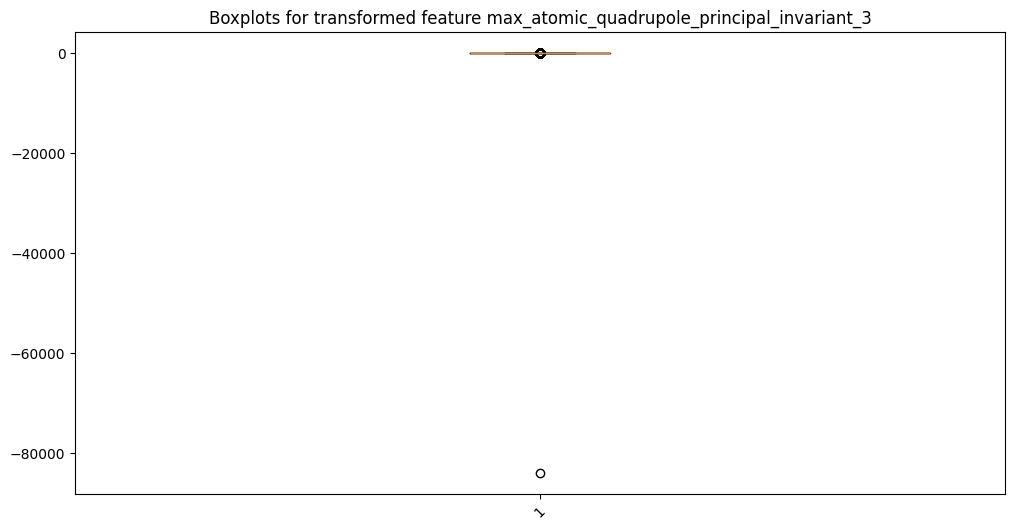

In [99]:
boxplot(X_trans_faulty, "max_atomic_quadrupole_principal_invariant_3")

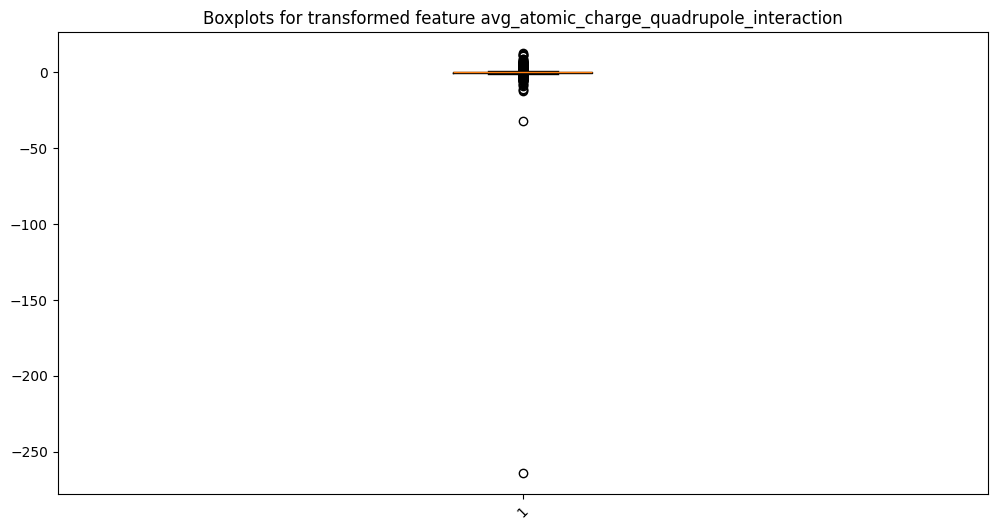

In [100]:
boxplot(X_trans_faulty, "avg_atomic_charge_quadrupole_interaction")

In [102]:
X = X.drop("max_atomic_quadrupole_principal_invariant_3", axis=1)
X = X.drop("avg_atomic_charge_quadrupole_interaction", axis=1)

In [103]:
scores = cross_validate(pl_linear, X, y, cv=cv, scoring=scoring, n_jobs=4, return_estimator=True, return_train_score=True)

In [106]:
print(f"Train R2 scores: {scores["train_r2"].mean()}\n\nTest R2 scores: {scores["test_r2"].mean()}")

Train R2 scores: 0.8477101784717606

Test R2 scores: 0.8274367874649752


In [107]:
repeated_cv = RepeatedKFold(n_splits=5, n_repeats=5, random_state=15)

In [115]:
scores3 = cross_validate(pl_linear, X, y, cv=repeated_cv, scoring=scoring, n_jobs=4, return_estimator=True, return_train_score=True)

KeyboardInterrupt: 

In [109]:
print(f"Train R2 scores: {scores3["train_r2"]}\n\nTest R2 scores: {scores3["test_r2"]}")

Train R2 scores: [0.84679965 0.85332204 0.84914154 0.84635553 0.84802682 0.84601347
 0.84799944 0.8472906  0.85007964 0.85192699 0.85042709 0.84825466
 0.84990778 0.84772098 0.84686665 0.84675224 0.84925549 0.84731884
 0.84714831 0.85214942 0.8472901  0.84855605 0.85350497 0.84489445
 0.84925283]

Test R2 scores: [ 8.40466777e-01  8.10361929e-01  8.29593031e-01  8.41745402e-01
 -1.13534071e+02  8.43360894e-01  8.19877773e-01  8.37759675e-01
  8.19495834e-01  8.16986525e-01  8.20285107e-01  8.26223285e-01
  8.26308931e-01  8.33322357e-01  8.37489283e-01  8.36261373e-01
  8.30739186e-01  8.37465935e-01  8.37708457e-01  8.15336326e-01
  8.38969912e-01 -8.81103040e+06  8.12316786e-01  8.46242743e-01
  7.54243679e-01]


In [111]:
X_trans_faulty = get_faulty_X(scores3)

-8811030.400029093


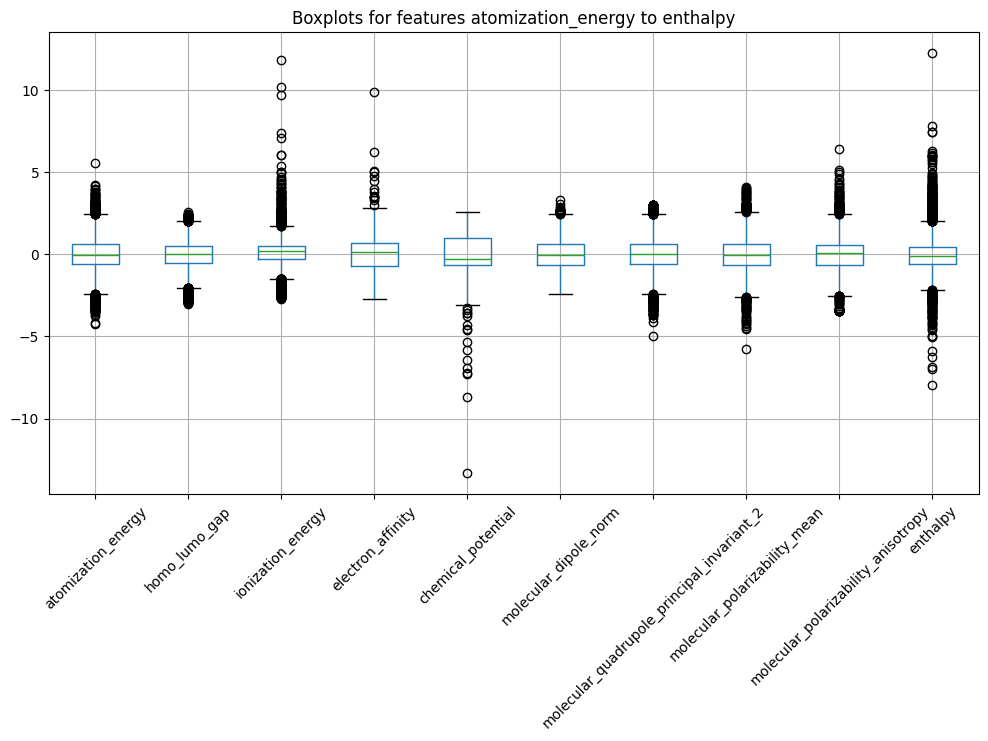

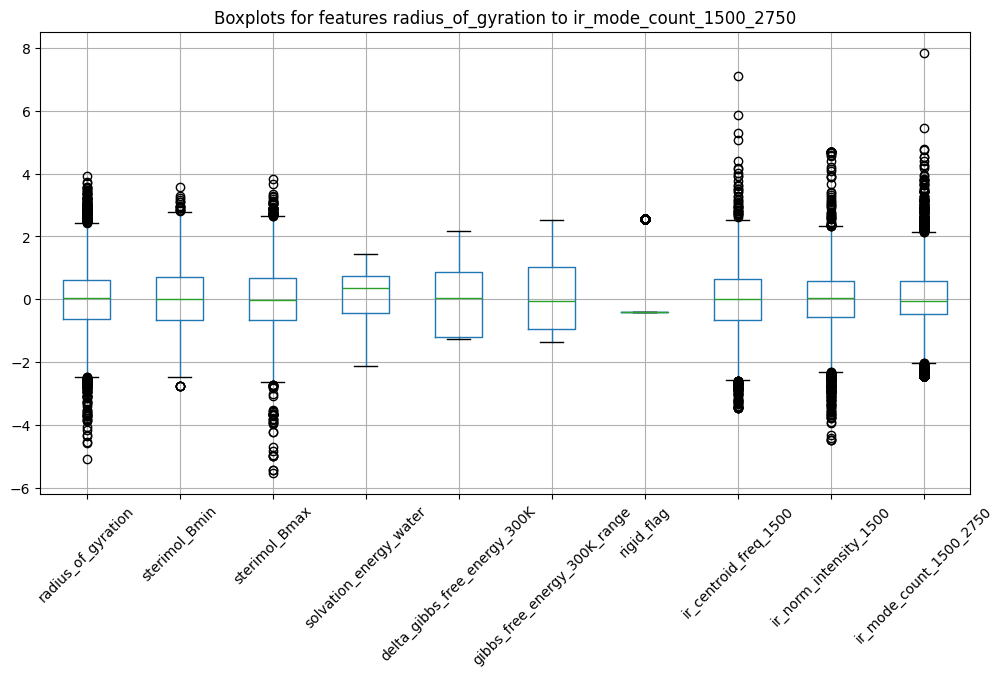

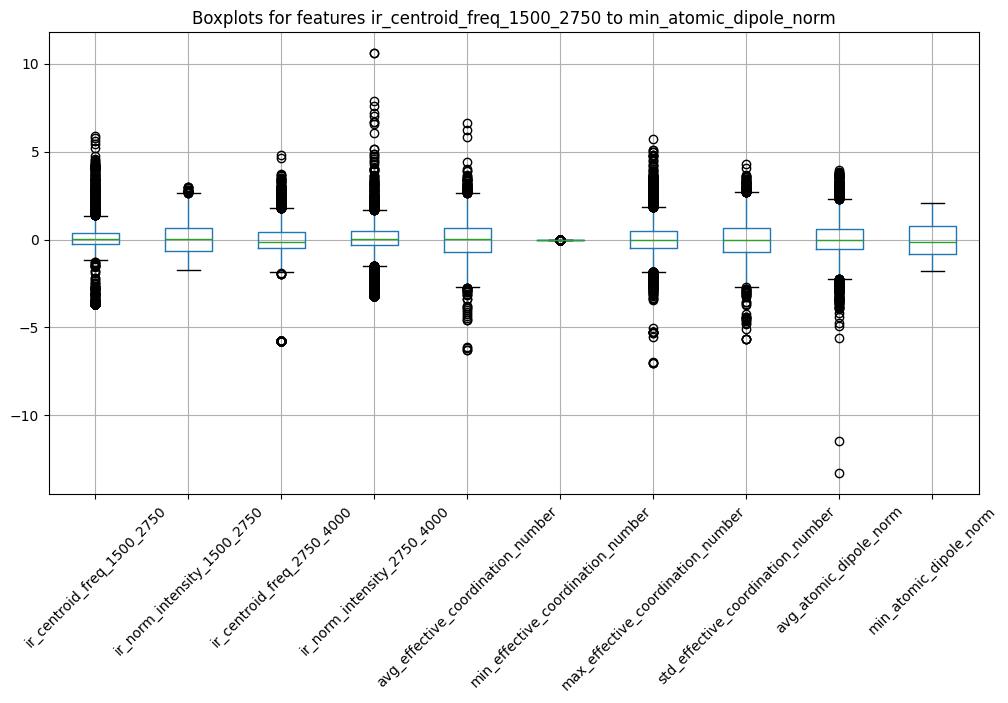

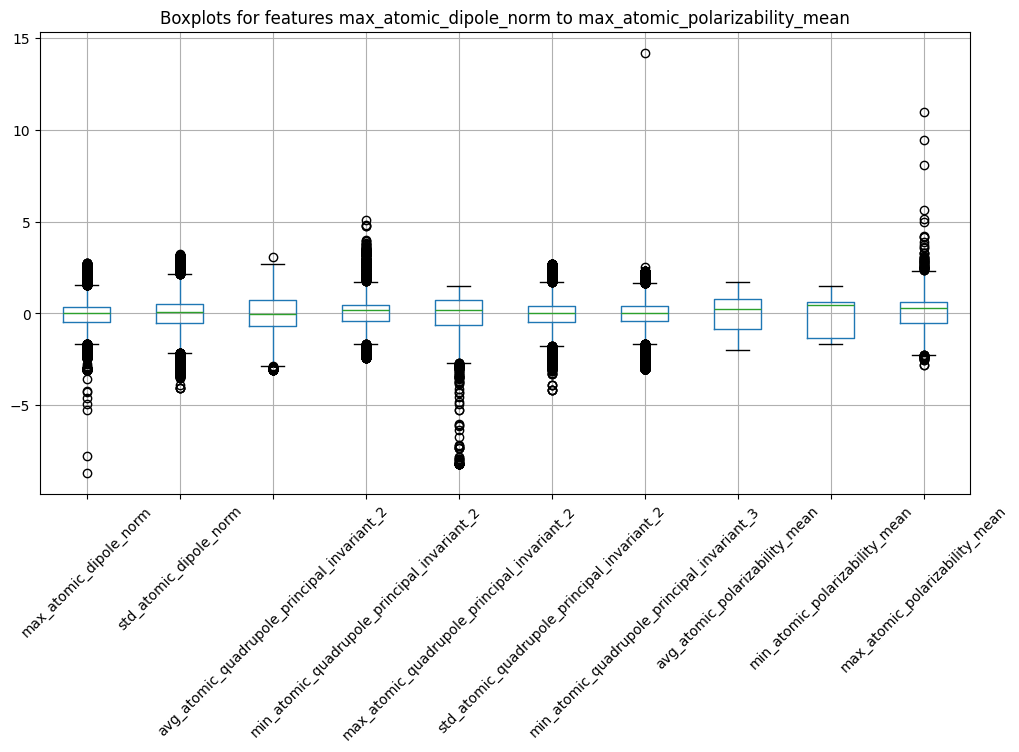

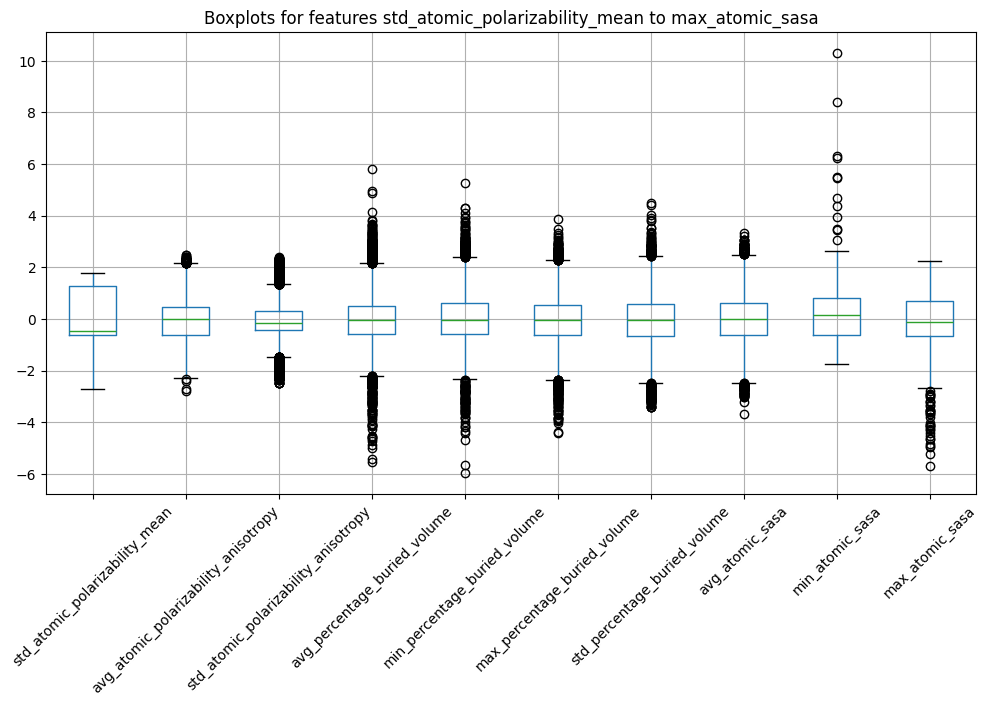

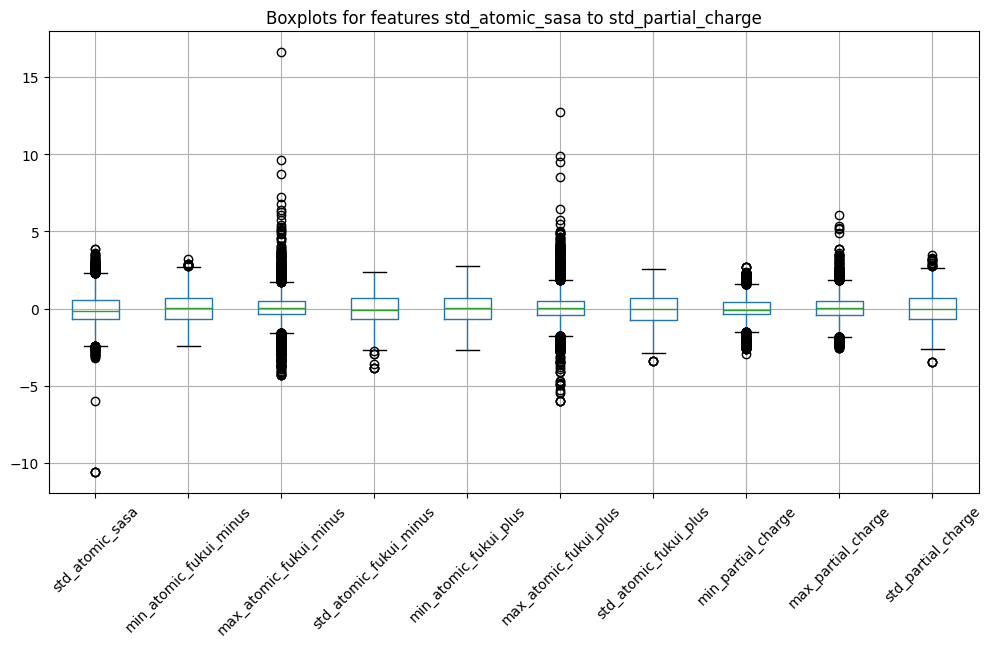

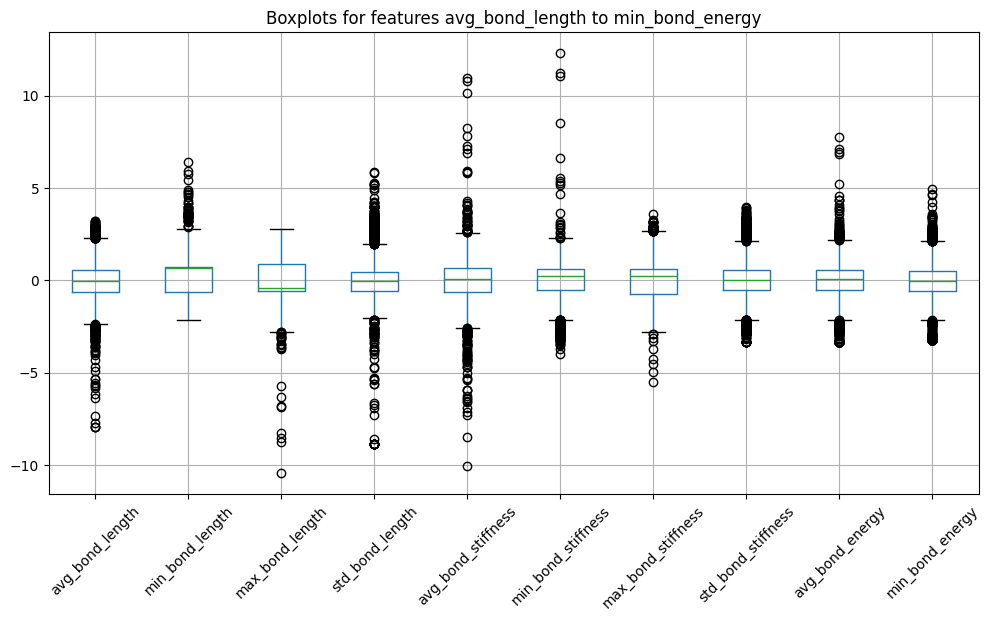

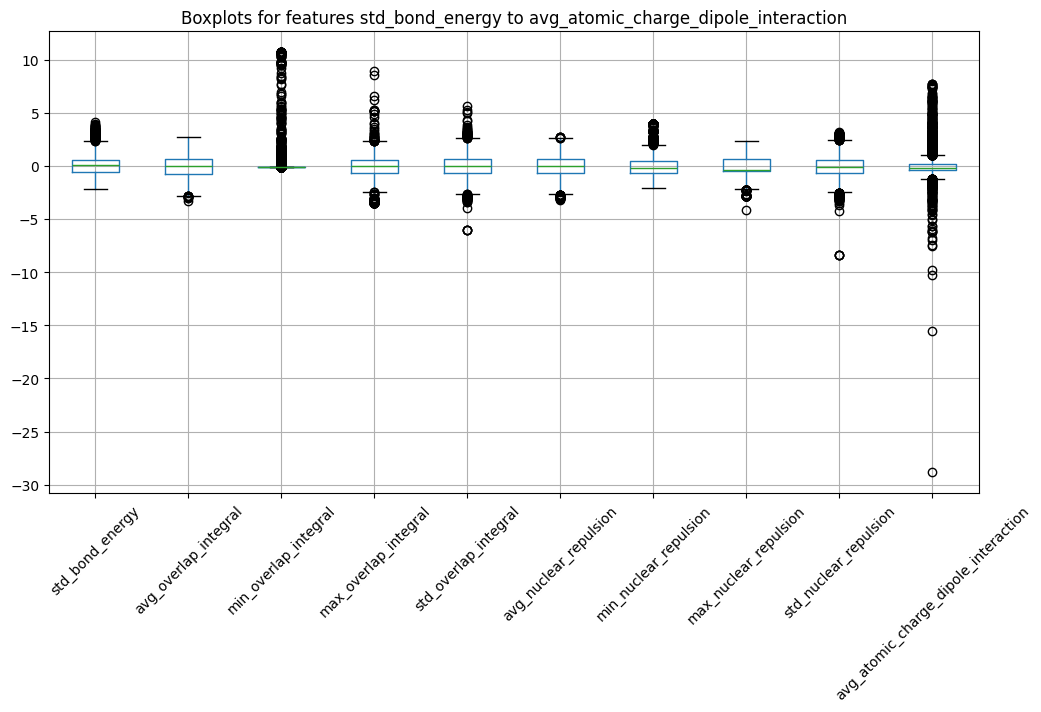

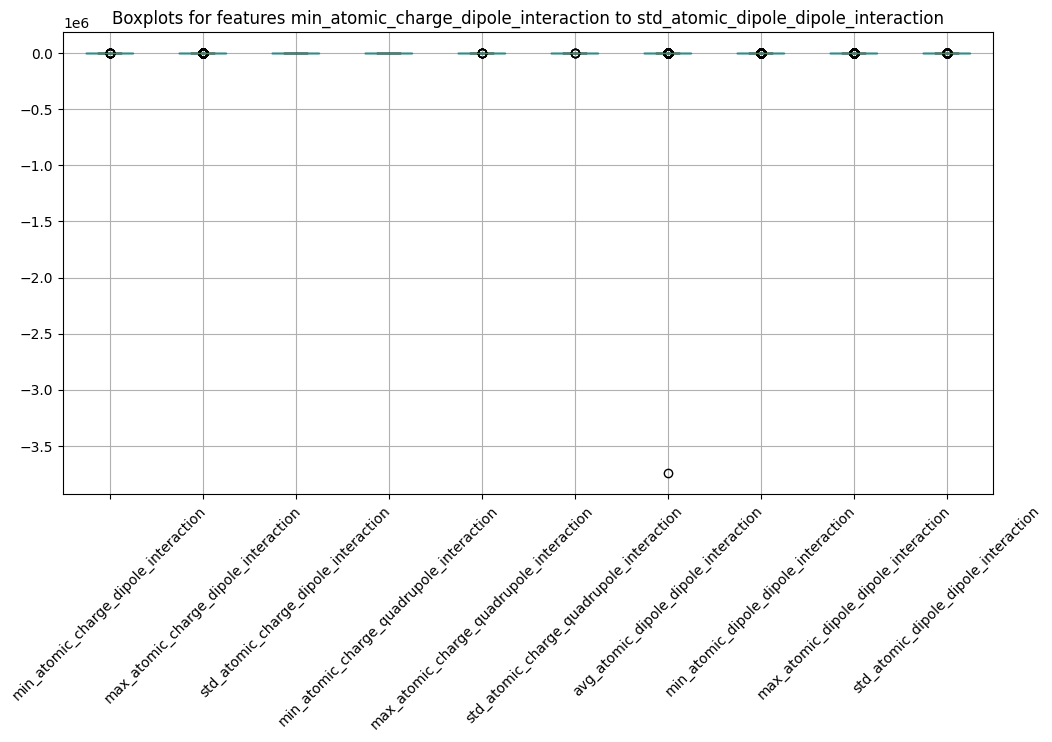

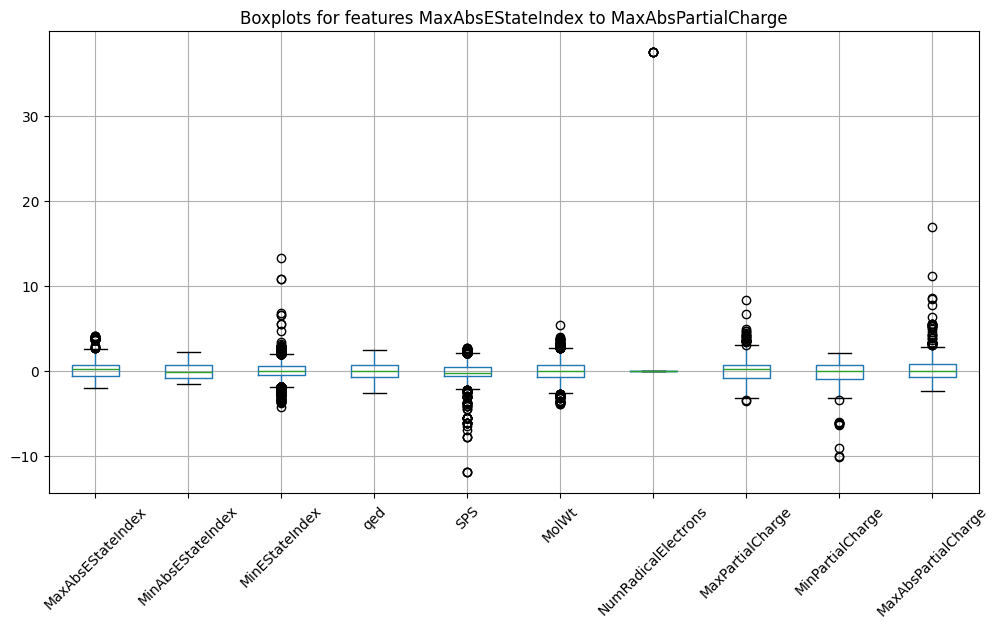

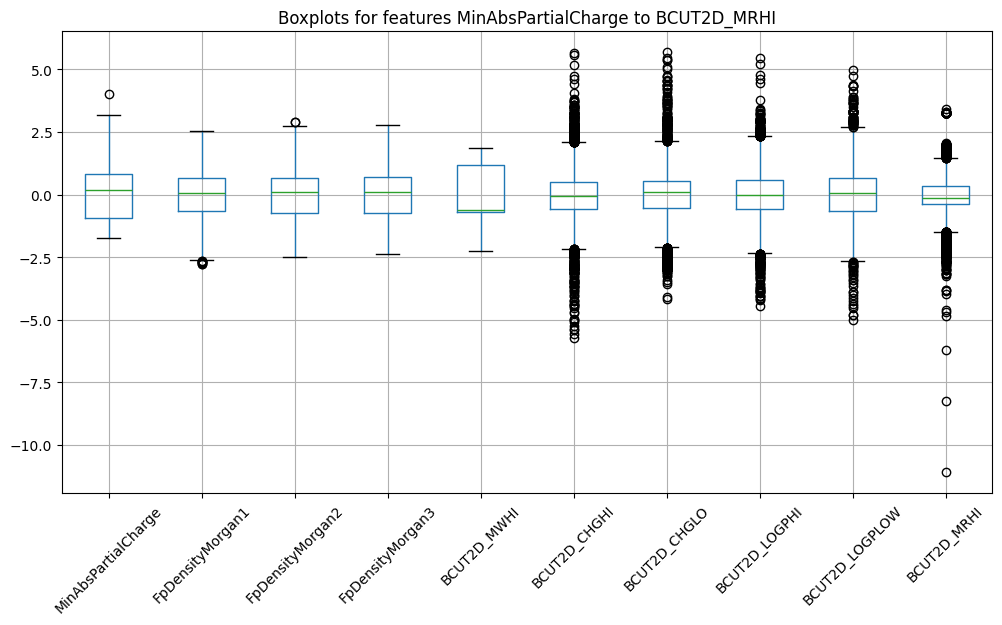

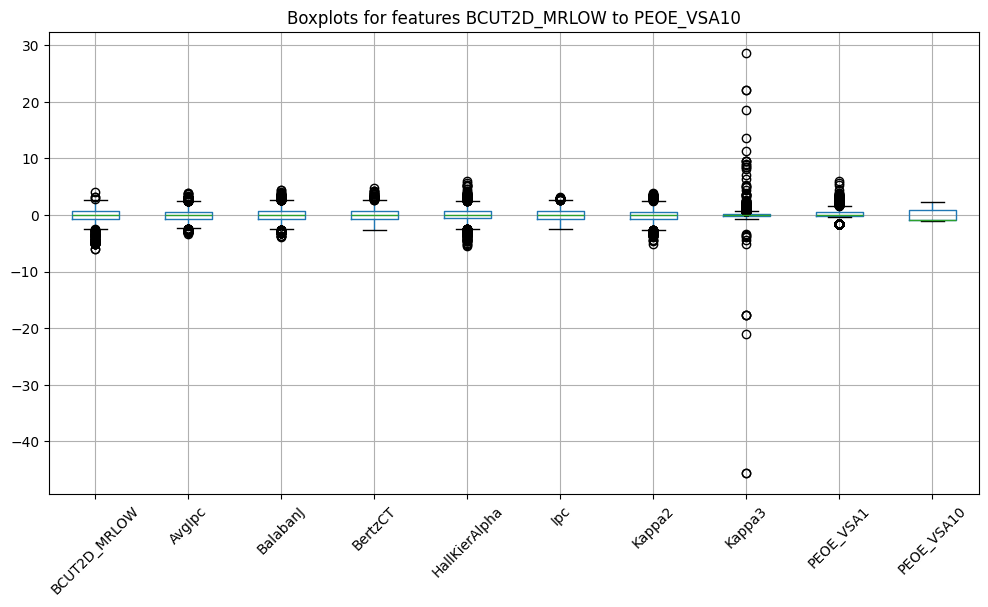

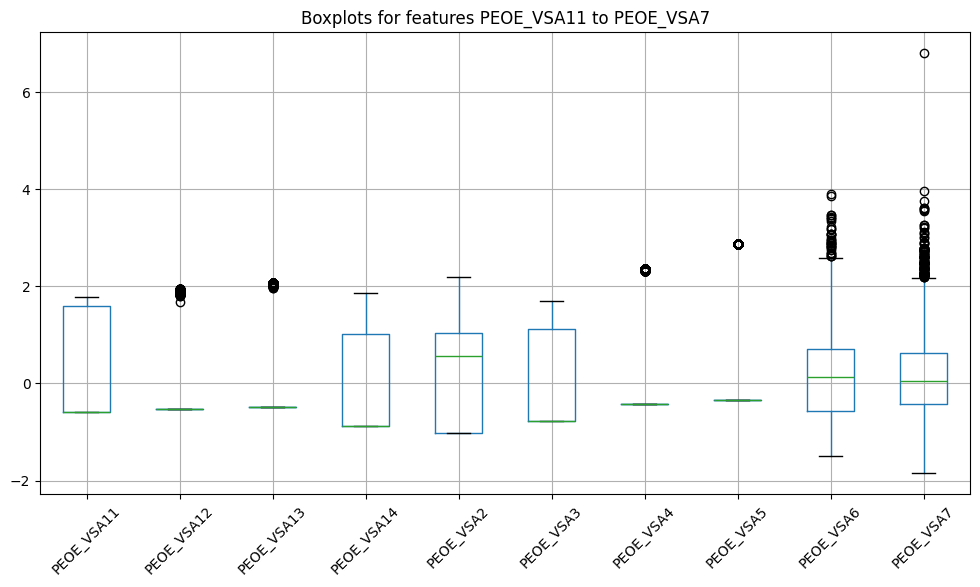

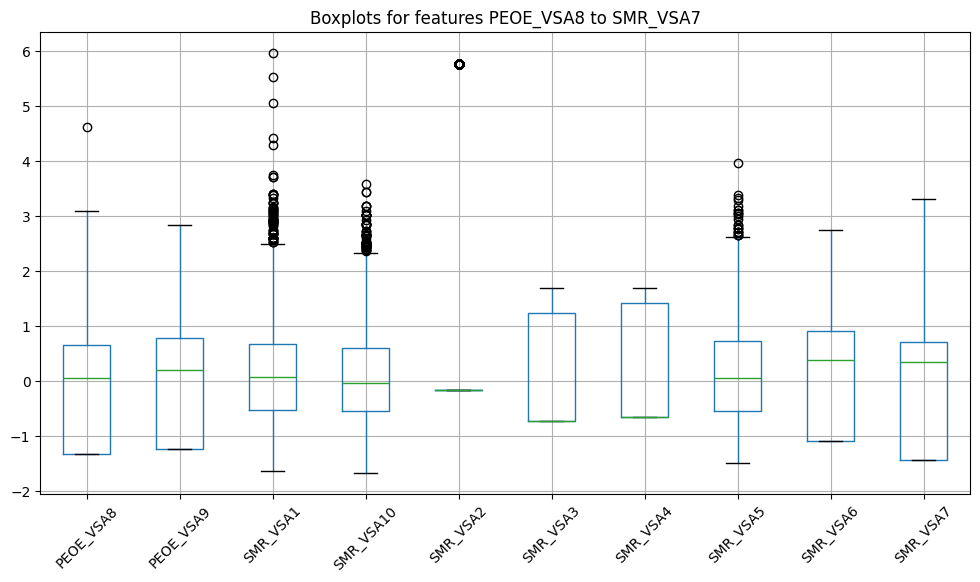

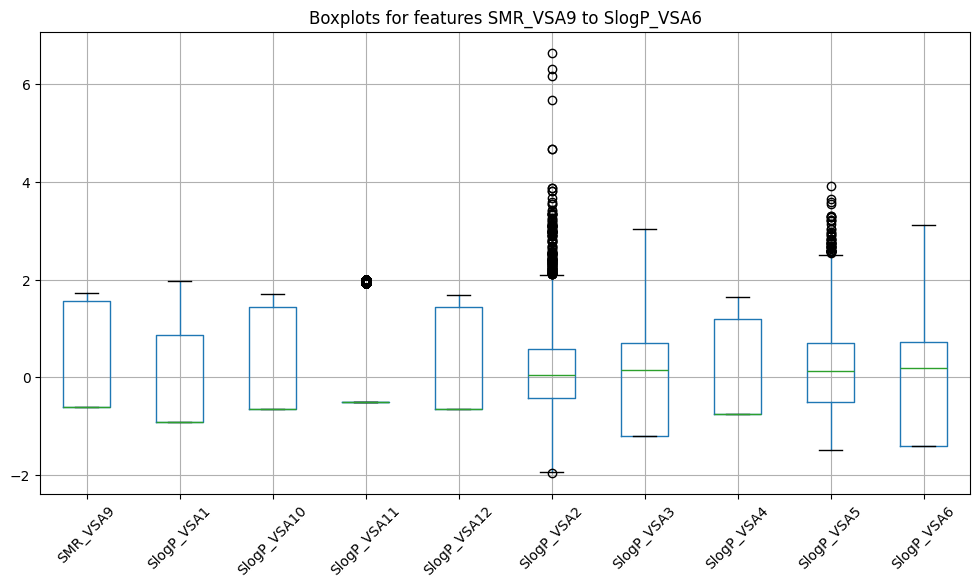

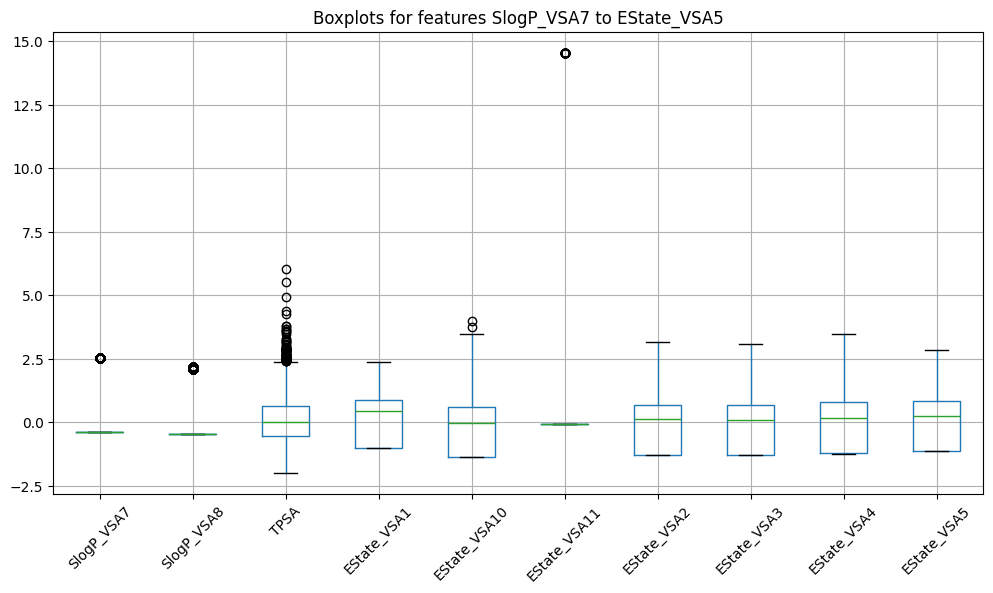

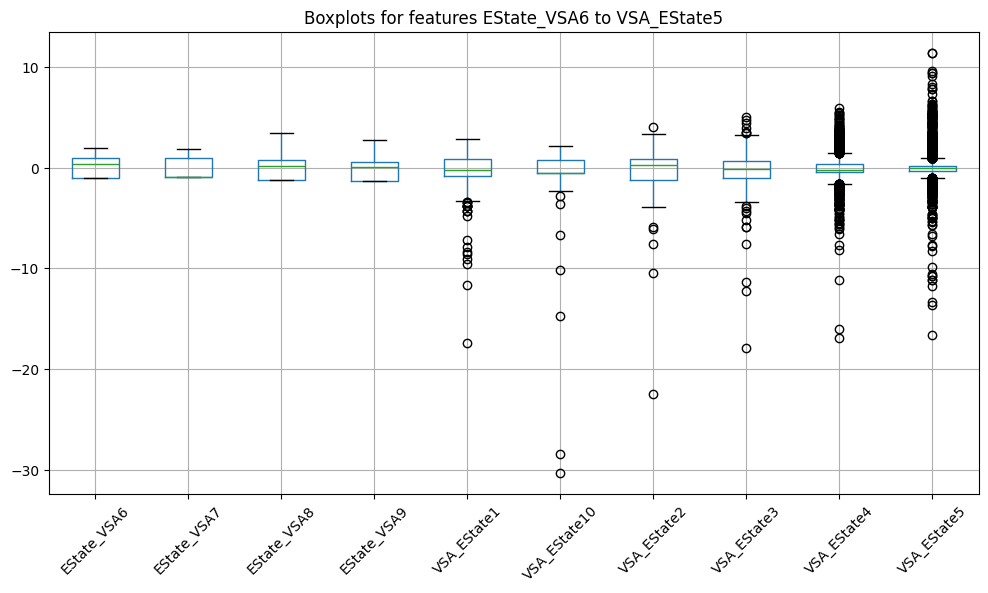

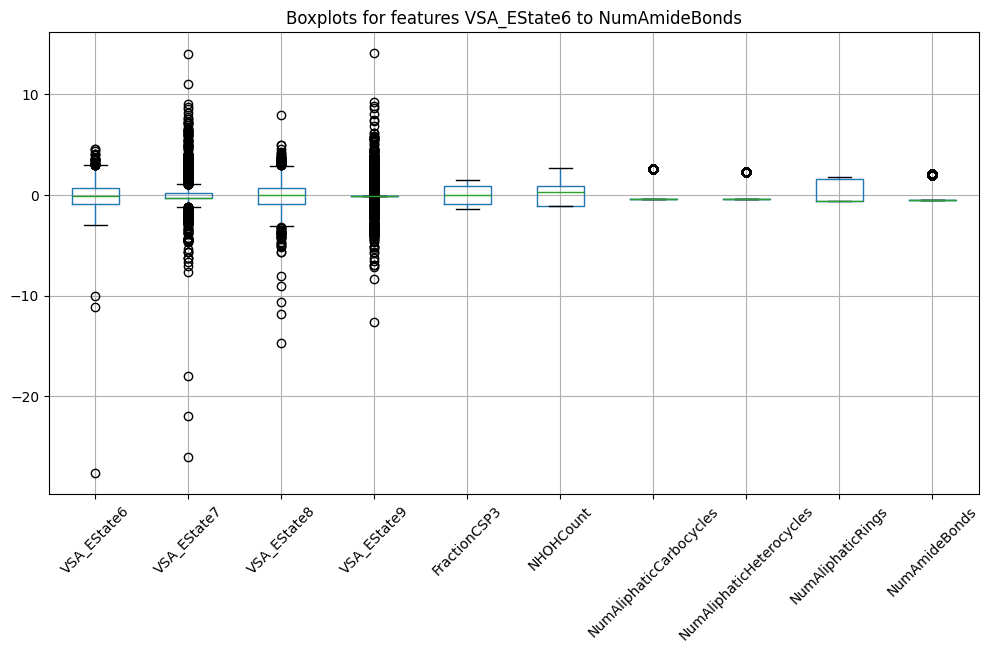

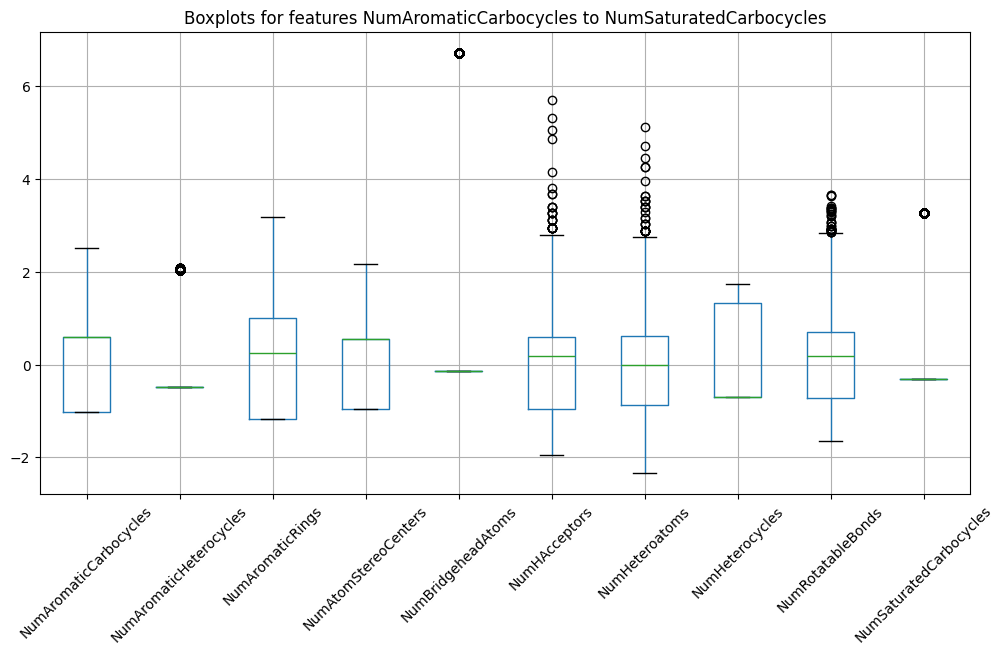

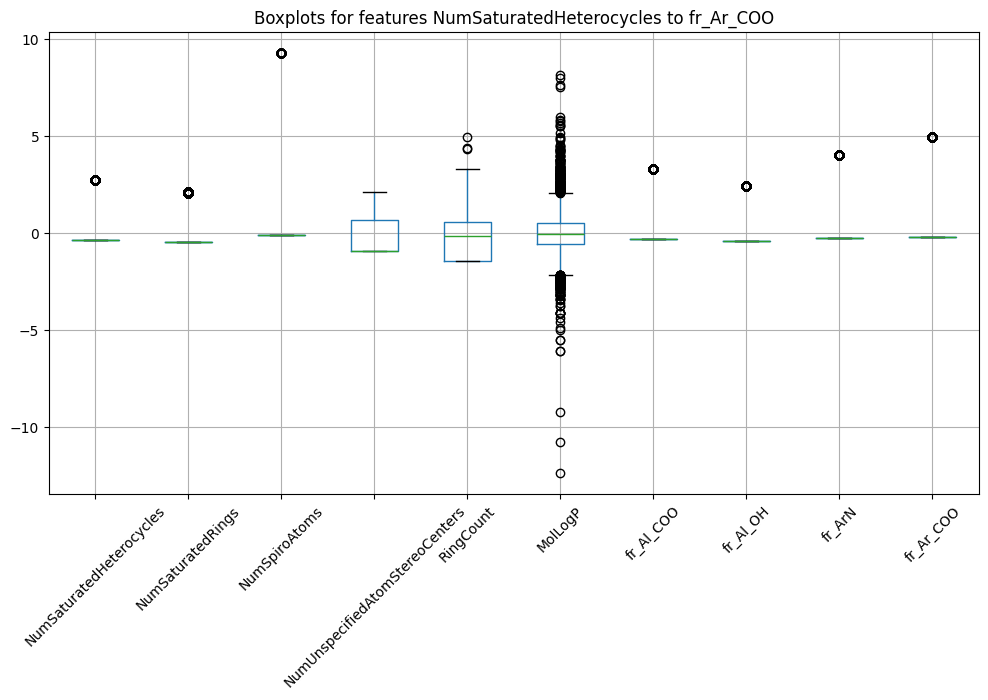

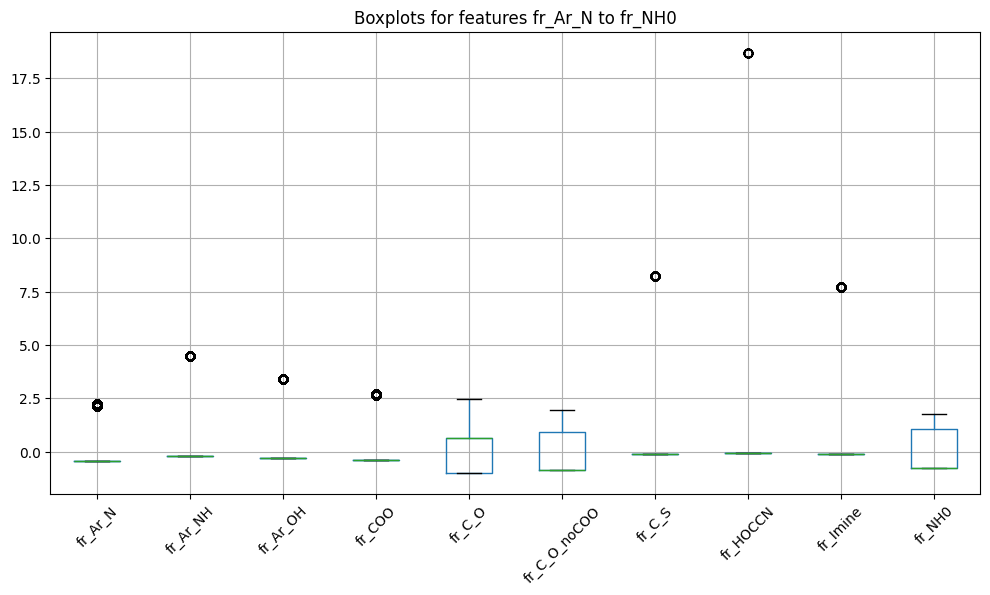

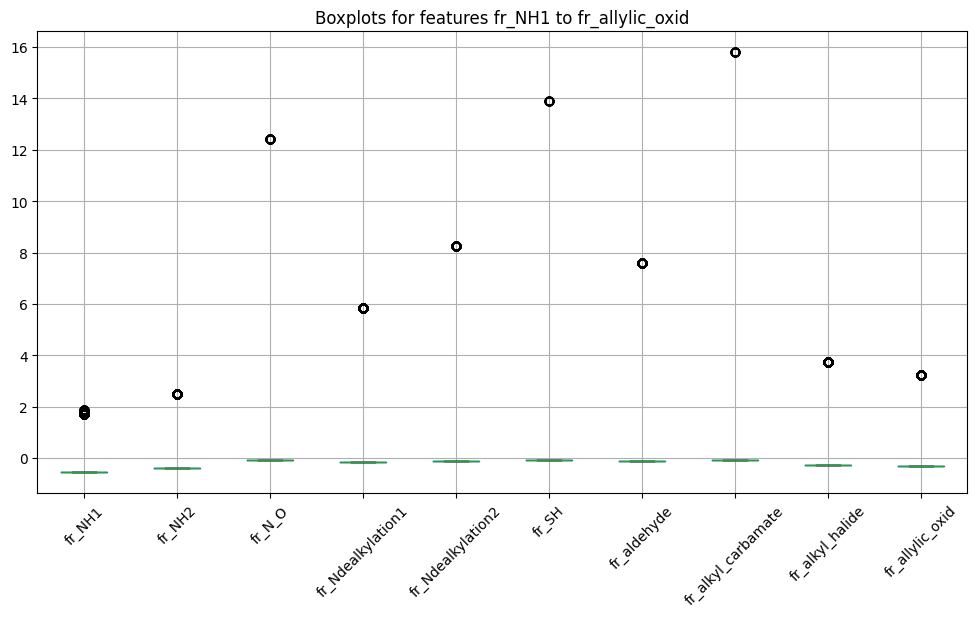

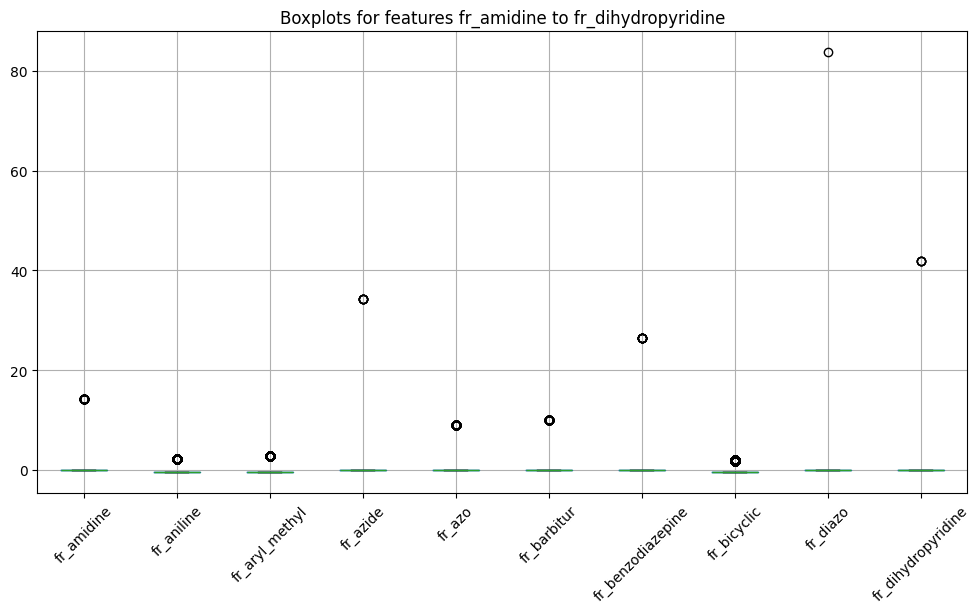

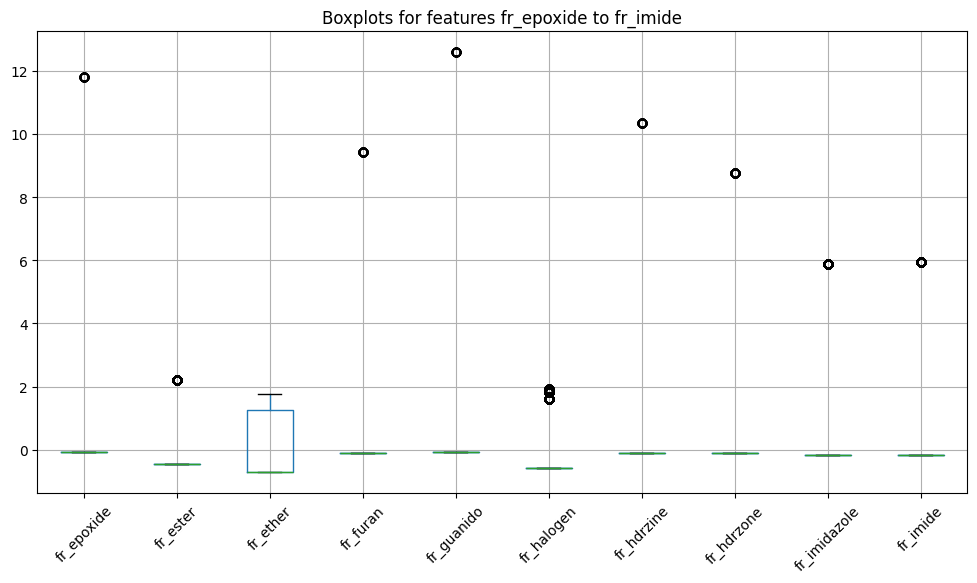

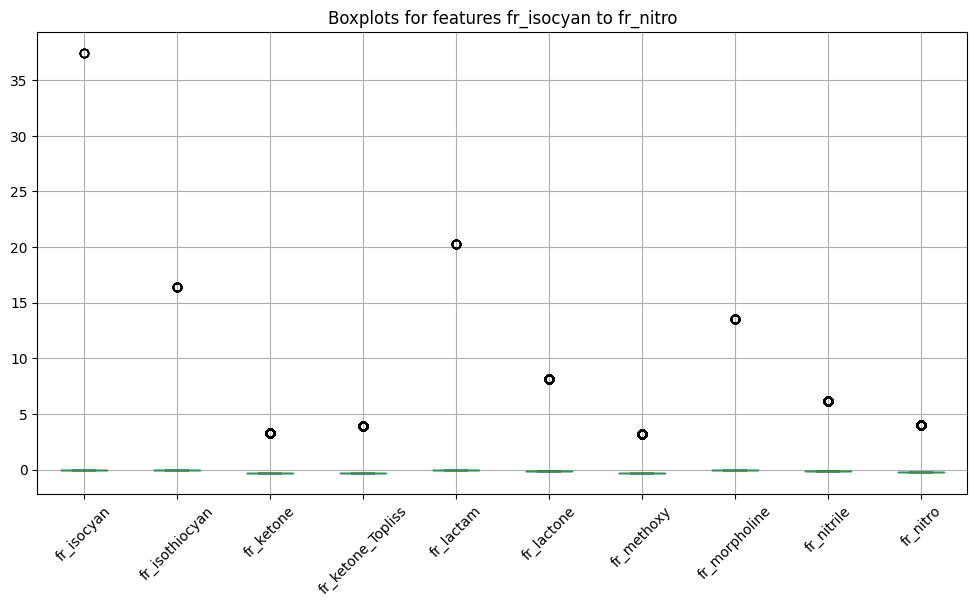

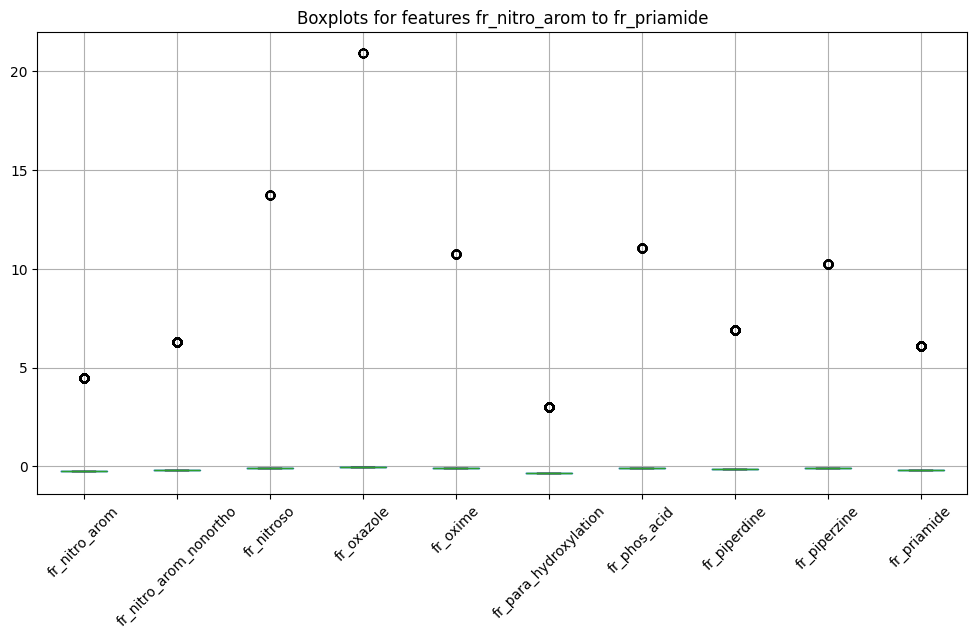

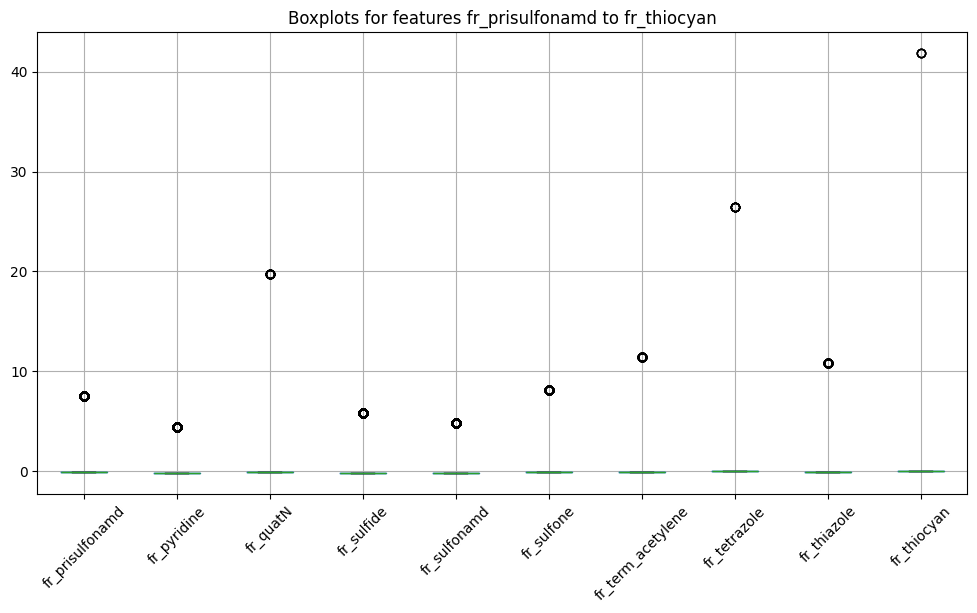

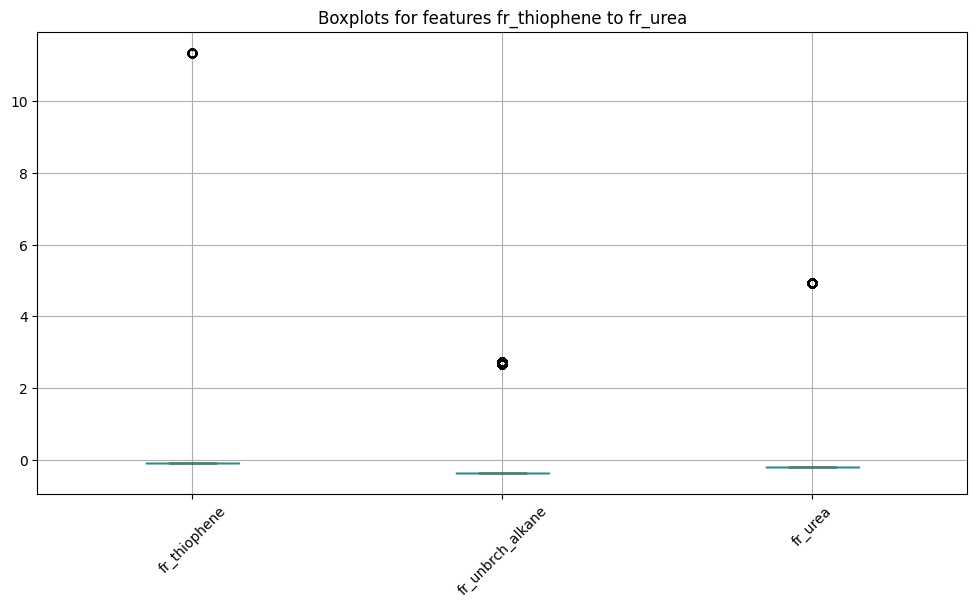

In [112]:
feature_groups = [X_trans_faulty.columns[i:i+10] for i in range(0, len(X_trans_faulty.columns), 10)]

for i, group in enumerate(feature_groups, 1):
    plt.figure(figsize=(12,6))
    X_trans_faulty[group].boxplot()
    plt.title(f'Boxplots for features {group[0]} to {group[-1]}')
    plt.xticks(rotation=45)
    plt.show()

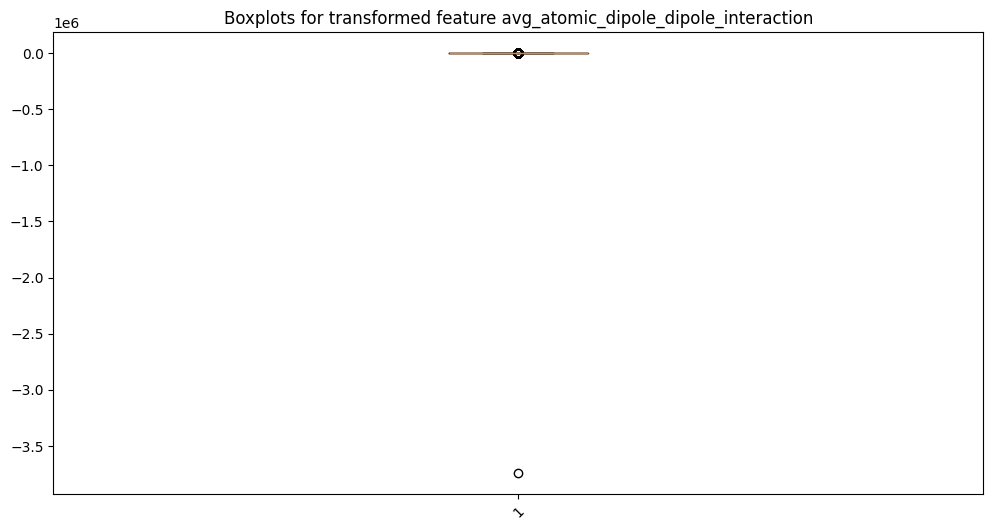

In [113]:
boxplot(X_trans_faulty, "avg_atomic_dipole_dipole_interaction")

In [114]:
X = X.drop("avg_atomic_dipole_dipole_interaction", axis=1)

In [116]:
scores4 = cross_validate(pl_linear, X, y, cv=repeated_cv, scoring=scoring, n_jobs=4, return_estimator=True, return_train_score=True)

In [117]:
print(f"Train R2 scores: {scores4["train_r2"]}\n\nTest R2 scores: {scores4["test_r2"]}")

Train R2 scores: [0.84676242 0.85331647 0.84913398 0.8463037  0.84801853 0.84598508
 0.84796331 0.84725004 0.84999155 0.85190452 0.85039069 0.848222
 0.84990351 0.84771719 0.84683759 0.84674535 0.84921097 0.84727003
 0.84714391 0.85214701 0.84727007 0.84833859 0.85346246 0.84485295
 0.84922485]

Test R2 scores: [  0.84053217   0.81042728   0.82953164   0.84171677 -10.14884658
   0.84342208   0.83306479   0.8378406    0.82035419   0.81707506
   0.82025746   0.82612821   0.82621341   0.83627158   0.83739466
   0.83618486   0.83088373   0.83777546   0.83766033   0.81736623
   0.8389589    0.83120612   0.81238124   0.84662706   0.76446699]
